# Pertemuan 7 — Pengantar Machine Learning: Regresi Linear

**Mata Kuliah:** Pengantar Data Science (Kode: 200302305)  
**Program Studi:** PJJ Informatika  
**Semester:** 4  
**Dosen:** Syahid Abdullah, S.Si, M.Kom

---

**Nama :** Junior Dany Wibisono  
**NIM  :** 250401020098  
**Angkatan:** 2025  
**Tanggal:** 30 Mei 2026

---

## Tujuan Notebook
Aktivitas hands-on Pertemuan 7 — membangun pipeline **Regresi Linear** end-to-end untuk memprediksi gaji:
1. Generate & eksplorasi dataset gaji sintetis (EDA singkat)
2. Preprocessing: One-Hot Encoding, train-test split, StandardScaler (anti data leakage)
3. Melatih model `LinearRegression` dan menginterpretasikan koefisien β
4. Evaluasi model dengan tiga metrik: **MAE**, **RMSE**, **R²**
5. Visualisasi & interpretasi: *Actual vs Predicted* dan *Residual Plot*

## Langkah 1 — Generate & Eksplorasi Dataset

Dataset gaji **sintetis** dibuat dengan pola realistis:
- `pengalaman` (0–20 tahun) → fitur numerik
- `edu` (0=SMA, 1=D3, 2=S1) → ordinal (sudah numerik)
- `kota` (Jakarta/Surabaya/Bandung) → kategorikal
- `gaji` (juta rupiah) → **target (y)**

Pola tersembunyi yang ditanamkan: `gaji ≈ 3.0 + 2.2·pengalaman + 1.5·edu + 4.0·(kota=Jakarta) + noise`.  
Nantinya model harus mampu "menemukan kembali" pola ini dari data.

In [ ]:
# Langkah 1: Generate dataset & EDA singkat
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu  = np.random.choice([0, 1, 2], n)              # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu,
                   'kota':kota, 'gaji':gaji})

print('Shape:', df.shape)
print('\n5 baris pertama:')
print(df.head().round(2).to_string(index=False))
print('\nStatistik deskriptif:')
print(df.describe().round(2).to_string())
print('\nDistribusi kota:')
print(df['kota'].value_counts().to_string())

Shape: (300, 4)

5 baris pertama:
 pengalaman  edu     kota  gaji
       7.49    0  Jakarta 21.95
      19.01    1  Jakarta 46.72
      14.64    2 Surabaya 34.95
      11.97    2  Bandung 32.44
       3.12    2  Jakarta 17.38

Statistik deskriptif:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22

Distribusi kota:
kota
Surabaya    106
Jakarta      97
Bandung      97


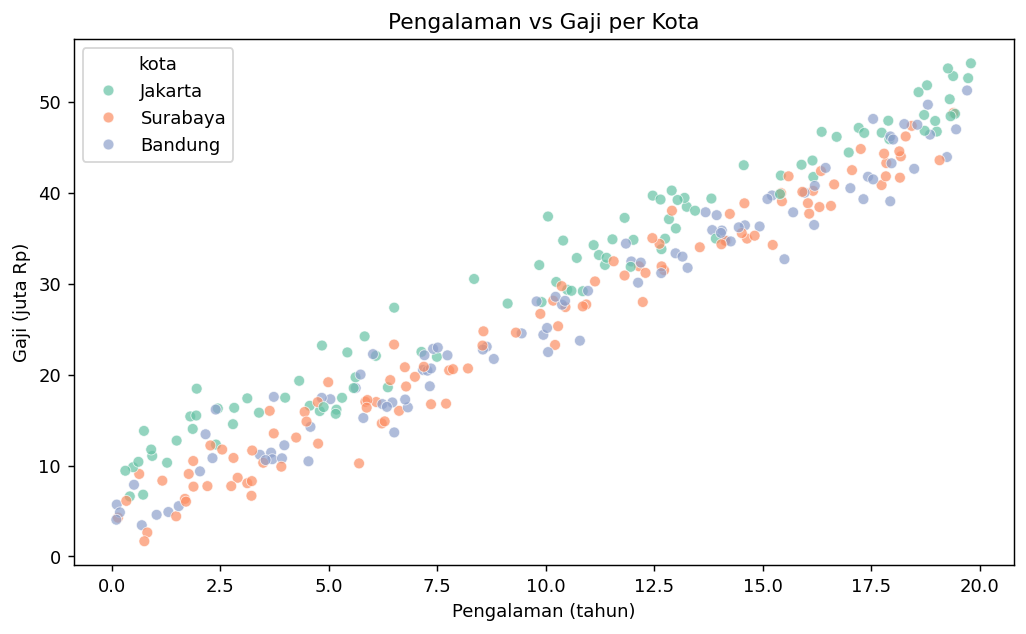

In [ ]:
# Visualisasi hubungan pengalaman vs gaji per kota
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota',
                palette='Set2', alpha=0.7)
plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman (tahun)'); plt.ylabel('Gaji (juta Rp)')
plt.tight_layout(); plt.show()

**Bacaan EDA:** terlihat tren **positif linear** — makin banyak pengalaman, makin tinggi gaji. Titik-titik kota Jakarta cenderung berada di atas (offset gaji lebih tinggi), konsisten dengan pola yang ditanamkan. Pola linear ini menjustifikasi penggunaan **Regresi Linear**.

## Langkah 2 — Preprocessing

Urutan yang benar untuk **mencegah data leakage**:
1. **One-Hot Encoding** kolom `kota` dengan `drop_first=True` (hindari *dummy variable trap*). `edu` dibiarkan numerik (ordinal).
2. Pisahkan fitur `X` dan target `y`, lalu **train-test split** (80:20).
3. **StandardScaler**: `fit_transform` **hanya** di data train, lalu `transform` di test.

In [ ]:
# Langkah 2a: One-Hot Encoding kolom 'kota'
df_enc = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df_enc.columns.tolist())
print()
print(df_enc.head().round(2).to_string(index=False))

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']

 pengalaman  edu  gaji  kota_Jakarta  kota_Surabaya
       7.49    0 21.95             1              0
      19.01    1 46.72             1              0
      14.64    2 34.95             0              1
      11.97    2 32.44             0              0
       3.12    2 17.38             1              0


In [ ]:
# Langkah 2b: Pisah fitur & target, lalu train-test split
from sklearn.model_selection import train_test_split

X = df_enc.drop('gaji', axis=1)
y = df_enc['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

Train: 240 baris, Test: 60 baris


In [ ]:
# Langkah 2c: Feature Scaling - fit di TRAIN saja (anti data leakage)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # belajar mean & std dari train
X_test_s  = scaler.transform(X_test)        # hanya transform, TIDAK fit ulang
print('Scaling selesai: fit_transform di train, transform di test.')

Scaling selesai: fit_transform di train, transform di test.


## Langkah 3 — Latih Model & Tampilkan Koefisien

Pola estimator scikit-learn: **Instantiate → Fit → Predict → Evaluate**.  
`LinearRegression` memakai **Ordinary Least Squares (OLS)** — solusi analitik langsung, bukan iterasi Gradient Descent.

In [ ]:
# Langkah 3: Latih model & lihat koefisien
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β0 (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

β0 (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


**Interpretasi koefisien** (catatan: fitur sudah **distandarisasi**, jadi koefisien menyatakan perubahan gaji per **1 standar deviasi** fitur, bukan per 1 unit asli):

- **`pengalaman` (+13.04)** → fitur paling dominan. Naik 1 SD pengalaman (~5,9 tahun) menaikkan gaji ±13 juta. Konsisten dengan slope asli 2,2 juta/tahun (2,2 × 5,9 ≈ 13).
- **`kota_Jakarta` (+1.84)** → bekerja di Jakarta cenderung menaikkan gaji dibanding baseline (Bandung), sesuai offset +4 juta yang ditanamkan.
- **`edu` (+1.19)** → pendidikan lebih tinggi → gaji naik, pengaruh moderat.
- **`kota_Surabaya` (−0.29)** → mendekati nol; Surabaya tidak berbeda banyak dari baseline.

Model berhasil **menemukan kembali** struktur data yang ditanamkan.

## Langkah 4 — Evaluasi Model

Tiga metrik utama regresi:
- **MAE** — rata-rata |error|, satuan sama dengan y, robust terhadap outlier
- **RMSE** — akar MSE, satuan sama dengan y, memberi penalti besar untuk outlier
- **R²** — proporsi variasi y yang dijelaskan model (0–1)

> Catatan: pada scikit-learn versi baru (≥1.6) parameter `squared=False` sudah dihapus. Gunakan `root_mean_squared_error()` atau `np.sqrt(mse)`.

In [ ]:
# Langkah 4: Hitung MAE, MSE, RMSE, R2
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             root_mean_squared_error, r2_score)

y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)   # = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'MSE  = {mse:.3f} (juta rupiah^2)')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2   = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')
print(f'Verifikasi R2 (model.score) = {model.score(X_test_s, y_test):.4f}')

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
MSE  = 4.507 (juta rupiah^2)
RMSE = 2.123 juta rupiah
R2   = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474
Verifikasi R2 (model.score) = 0.9740


**Interpretasi metrik:**
- **MAE = 1,65 juta** → rata-rata prediksi gaji meleset ±1,65 juta rupiah dari nilai aktual. Sangat kecil dibanding rata-rata gaji ~27 juta.
- **RMSE = 2,12 juta** → selisih RMSE−MAE hanya **0,47 juta** (kecil), artinya kesalahan cukup **seragam** dan **tidak ada outlier** yang mendominasi prediksi.
- **R² = 0,974** → model menjelaskan **97,4%** variasi gaji → kategori **Sangat Baik**. Wajar karena dataset sintetis memang dibangun linear; pada data nyata R² setinggi ini perlu diwaspadai sebagai indikasi overfitting/kebocoran data.

## Langkah 5 — Visualisasi & Interpretasi

Dua plot standar evaluasi regresi:
- **Actual vs Predicted** — makin dekat titik ke garis diagonal (prediksi sempurna), makin baik.
- **Residual Plot** — idealnya titik tersebar **acak** di sekitar garis y=0, tanpa pola.

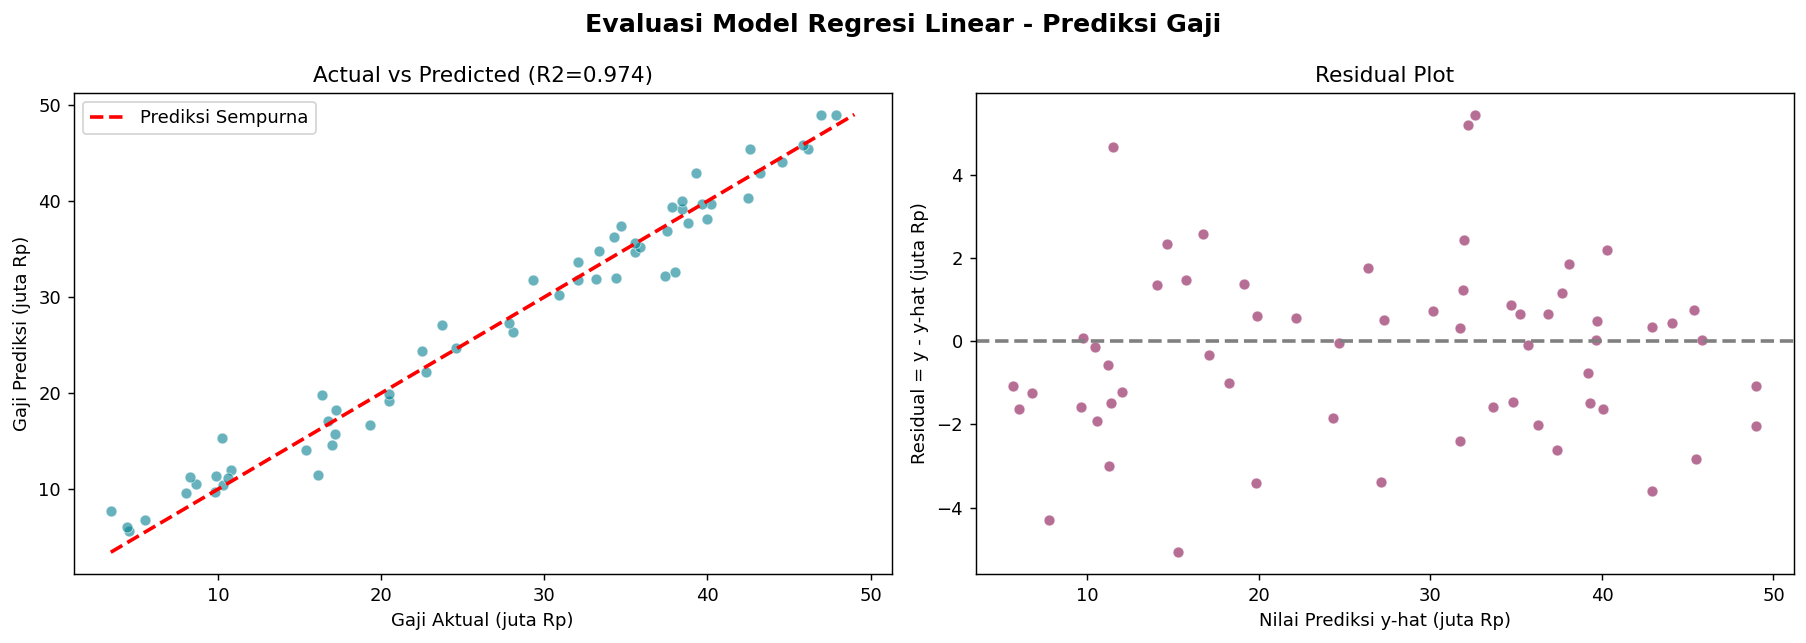

In [ ]:
# Langkah 5: Actual vs Predicted & Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='#028090',
                edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='#880E4F',
                edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

**Membaca grafik (What? So what? Now what?):**

- **What?** Pada *Actual vs Predicted*, titik-titik menempel rapat di garis diagonal merah. Pada *Residual Plot*, residual tersebar acak di sekitar garis nol tanpa pola corong/kurva.
- **So what?** Model memprediksi gaji dengan akurat dan **asumsi linearitas terpenuhi** — tidak ada bias sistematis (model tidak konsisten over/under-predict di rentang tertentu).
- **Now what?** Model layak dipakai sebagai *baseline*. Untuk data nyata, langkah lanjut: tambah fitur relevan, uji algoritma lain (Ridge/Random Forest), dan validasi silang (cross-validation) untuk memastikan generalisasi.

## Refleksi Singkat

Melalui aktivitas ini saya membangun pipeline Machine Learning pertama saya secara utuh: dari generate & eksplorasi data, preprocessing yang benar (encoding → split → scaling untuk mencegah data leakage), melatih `LinearRegression`, hingga mengevaluasinya dengan MAE, RMSE, dan R². Saya memahami bahwa koefisien model harus diinterpretasikan sesuai konteks (di sini dalam satuan terstandarisasi), dan bahwa visualisasi *Actual vs Predicted* serta *Residual Plot* sama pentingnya dengan angka metrik. Hasil R² = 0,974 sangat baik, namun saya menyadari nilai setinggi ini wajar karena datanya sintetis — pada data dunia nyata diperlukan kewaspadaan terhadap overfitting. Pertemuan ini menutup rangkaian dari data mentah hingga model prediktif, dan memantapkan langkah saya menuju cita-cita sebagai Data Scientist.